# 05 — Model Evaluation

Loads the latest trained artifact and inspects it: metrics, threshold rationale, and the standard evaluation plots.

In [1]:
from bnpl_credit_risk.models.persistence import ArtifactBundle
from bnpl_credit_risk.models.registry import resolve_model_dir
from bnpl_credit_risk.settings import get_settings, load_config

settings = get_settings()
config = load_config()
models_dir = settings.resolve(settings.artifacts_dir) / 'models'
bundle = ArtifactBundle.load(resolve_model_dir(models_dir, 'latest'))
bundle.version, bundle.metrics['test']['roc_auc'], bundle.threshold

('2026-07-13_075445',
 0.7773922062527782,
 {'threshold': 0.04840698838233948,
  'policy': 'best_f1',
  'rationale': 'Threshold maximizing F1 on out-of-fold train predictions (F1=0.6583).',
  'risk_bands': [{'name': 'Low Risk', 'max_probability': 0.25},
   {'name': 'Medium Risk', 'max_probability': 0.5},
   {'name': 'High Risk', 'max_probability': 0.75},
   {'name': 'Very High Risk', 'max_probability': 1.01}]})

In [2]:
from bnpl_credit_risk.data.loaders import BNPLDataLoader
from bnpl_credit_risk.data.splitting import get_splitter

df = BNPLDataLoader(settings, config.data).load_raw()
splitter = get_splitter(config.training.split.strategy, config.training.split,
                        id_column=config.data.id_column, date_column=config.data.date_column,
                        target_column=config.data.target_column)
_, test_df = splitter.split(df)
X_test = test_df.drop(columns=[config.data.target_column])
y_test = test_df[config.data.target_column]
y_prob = bundle.pipeline.predict_proba(X_test)[:, 1]

2026-07-13 07:54:56.517 | INFO     | bnpl_credit_risk.data.loaders:load_raw:37 - Loaded raw dataset path=/Users/surelmanda/BNPL-Credit-Risk/data/raw/BNPL_CreditRisk_Dataset.csv rows=10345 columns=17


2026-07-13 07:54:56.520 | INFO     | bnpl_credit_risk.data.splitting:split:90 - Time-based split: train up to 2024-10-18 00:00:00, test from 2024-10-18 00:00:00 onward


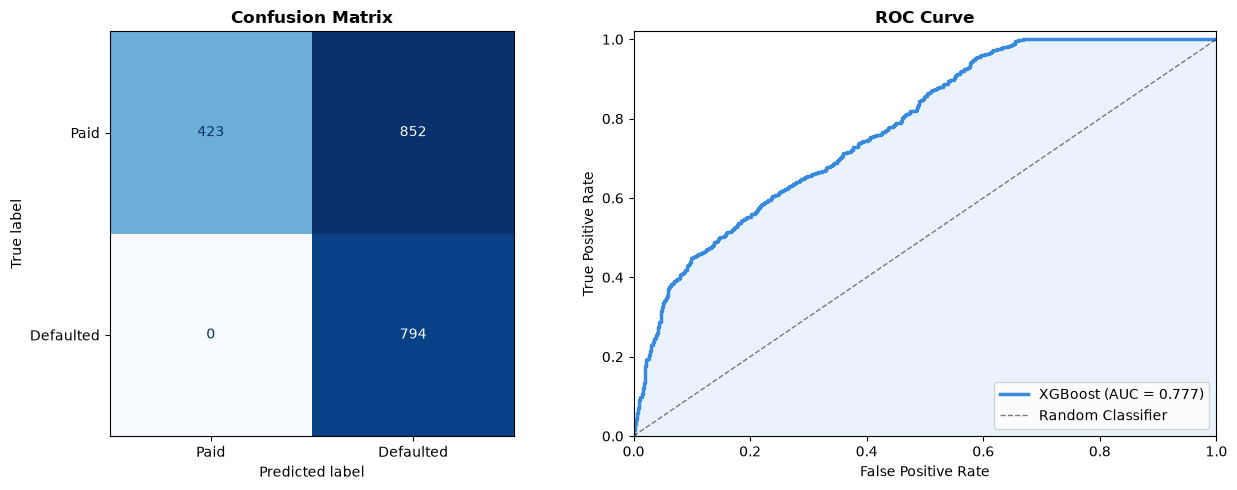

In [3]:
from bnpl_credit_risk.visualization.evaluation import (
                        plot_confusion_matrix_and_roc,
                        plot_probability_distribution,
)

y_pred = (y_prob >= bundle.threshold['threshold']).astype(int)
_ = plot_confusion_matrix_and_roc(y_test.to_numpy(), y_pred, y_prob)

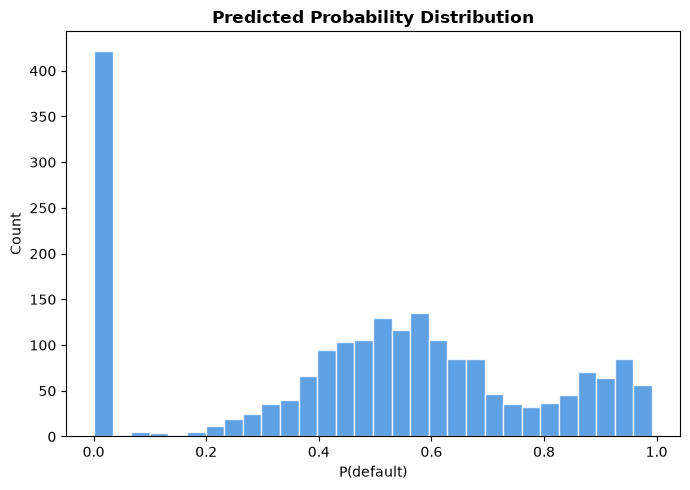

In [4]:
_ = plot_probability_distribution(y_prob)

## Calibration

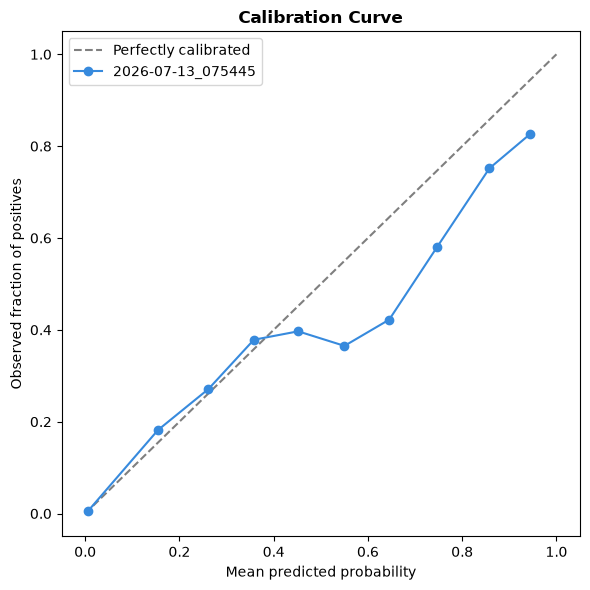

In [5]:
from bnpl_credit_risk.visualization.calibration import plot_calibration_curve

_ = plot_calibration_curve(y_test.to_numpy(), y_prob, label=bundle.version)